# DRIVER BEHAVIOR DATA

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

In [28]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

Loading Data Set

In [29]:
df = pd.read_csv("driver_behavior.csv")

In [30]:
print(df.head())

   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle   throttle  \
0   36.075011  0.535763  0.708633       23.107812       -3.169956  53.123505   
1   38.090536  0.973764  0.044312       36.961137      -24.380082  36.383904   
2   71.314445  3.638434  0.789375       79.734087       -6.100238  78.110507   
3   86.485997  2.441366  0.039135       45.007002       17.886191  82.794935   
4   52.816777 -0.201763  0.560619       38.759612       -4.104323  61.432375   

   lane_deviation  phone_usage  headway_distance  reaction_time behavior_label  
0        0.851871            1         17.996005       1.400050     Distracted  
1        1.459495            1         29.904182       1.428537     Distracted  
2        0.254723            0         11.126012       0.406950     Aggressive  
3        0.911664            0         11.064505       0.539964     Aggressive  
4        1.591244            1         21.967570       1.369908     Distracted  


Info

In [31]:
print(df.dtypes)

speed_kmph          float64
accel_x             float64
accel_y             float64
brake_pressure      float64
steering_angle      float64
throttle            float64
lane_deviation      float64
phone_usage           int64
headway_distance    float64
reaction_time       float64
behavior_label       object
dtype: object


In [32]:
print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)



Dataset Shape:
(30000, 11)

Column Names:
Index(['speed_kmph', 'accel_x', 'accel_y', 'brake_pressure', 'steering_angle',
       'throttle', 'lane_deviation', 'phone_usage', 'headway_distance',
       'reaction_time', 'behavior_label'],
      dtype='object')


In [33]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   speed_kmph        30000 non-null  float64
 1   accel_x           30000 non-null  float64
 2   accel_y           30000 non-null  float64
 3   brake_pressure    30000 non-null  float64
 4   steering_angle    30000 non-null  float64
 5   throttle          30000 non-null  float64
 6   lane_deviation    30000 non-null  float64
 7   phone_usage       30000 non-null  int64  
 8   headway_distance  30000 non-null  float64
 9   reaction_time     30000 non-null  float64
 10  behavior_label    30000 non-null  object 
dtypes: float64(9), int64(1), object(1)
memory usage: 2.5+ MB
None


In [34]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
         speed_kmph       accel_x       accel_y  brake_pressure  \
count  30000.000000  30000.000000  30000.000000    30000.000000   
mean      59.986424      1.265818      0.368501       40.767624   
std       14.806008      1.026624      0.295654       26.721728   
min       20.000000     -0.949617     -0.479718        0.003128   
25%       49.568893      0.506529      0.116047       18.722464   
50%       57.901281      0.831602      0.313145       39.951206   
75%       69.242746      1.968167      0.568768       57.914900   
max      118.439831      5.308924      1.664605       99.994365   

       steering_angle      throttle  lane_deviation   phone_usage  \
count    30000.000000  30000.000000    30000.000000  30000.000000   
mean        -0.040207     55.001223        0.568549      0.333333   
std         11.384086     21.475323        0.420563      0.471412   
min        -59.989984     20.001444        0.000001      0.000000   
25%         -6.215165     37.

Checking Missing Values

In [35]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
speed_kmph          0
accel_x             0
accel_y             0
brake_pressure      0
steering_angle      0
throttle            0
lane_deviation      0
phone_usage         0
headway_distance    0
reaction_time       0
behavior_label      0
dtype: int64


In [36]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].mean())

In [37]:
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



Missing Values After Cleaning:
speed_kmph          0
accel_x             0
accel_y             0
brake_pressure      0
steering_angle      0
throttle            0
lane_deviation      0
phone_usage         0
headway_distance    0
reaction_time       0
behavior_label      0
dtype: int64


Removeing Duplicate Rows

In [38]:
print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)


Duplicate Rows: 0
Shape After Removing Duplicates: (30000, 11)


Outlier Detection

In [39]:

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nShape After Removing Outliers:")
print(df.shape)


Shape After Removing Outliers:
(27656, 11)


Data Transformation

In [40]:
le = LabelEncoder()

df['behavior_label_encoded'] = le.fit_transform(df['behavior_label'])

print("\nBehavior Classes:")
print(dict(zip(le.classes_, le.transform(le.classes_))))



Behavior Classes:
{'Aggressive': np.int64(0), 'Distracted': np.int64(1), 'Safe': np.int64(2)}


In [41]:
scaler = StandardScaler()

feature_cols = [
    'speed_kmph',
    'accel_x',
    'accel_y',
    'brake_pressure',
    'steering_angle',
    'throttle',
    'lane_deviation',
    'phone_usage',
    'headway_distance',
    'reaction_time'
]

df_scaled = df.copy()

df_scaled[feature_cols] = scaler.fit_transform(df_scaled[feature_cols])

print("\nScaled Data Sample:")
print(df_scaled.head())



Scaled Data Sample:
   speed_kmph   accel_x   accel_y  brake_pressure  steering_angle  throttle  \
0   -1.646197 -0.677689  1.264479       -0.605615       -0.333874 -0.029914   
1   -1.502903 -0.228698 -1.078528       -0.084025       -2.575153 -0.817606   
2    0.859157  2.502836  1.549250        1.526413       -0.643518  1.145865   
3    1.937781  1.275730 -1.096786        0.218909        1.891133  1.366293   
4   -0.455938 -1.433722  0.742446       -0.016311       -0.432609  0.361065   

   lane_deviation  phone_usage  headway_distance  reaction_time  \
0        0.756130     1.414866         -0.503335       0.850947   
1        2.271441     1.414866          0.479102       0.912802   
2       -0.733058    -0.706781         -1.070117      -1.305385   
3        0.905243    -0.706781         -1.075191      -1.016568   
4        2.600000     1.414866         -0.175677       0.785500   

  behavior_label  behavior_label_encoded  
0     Distracted                       1  
1     Distracte

Exploratory Data Analysis

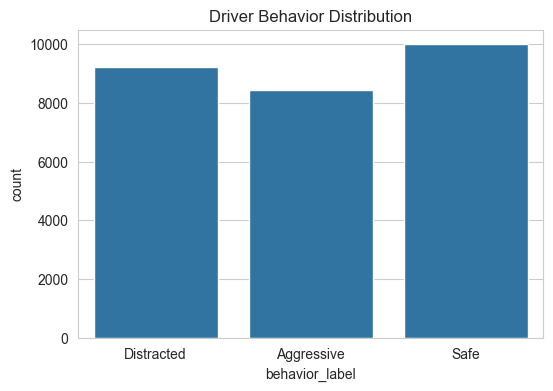

In [42]:
plt.figure(figsize=(6,4))
sns.countplot(x='behavior_label', data=df)
plt.title("Driver Behavior Distribution")
plt.show()

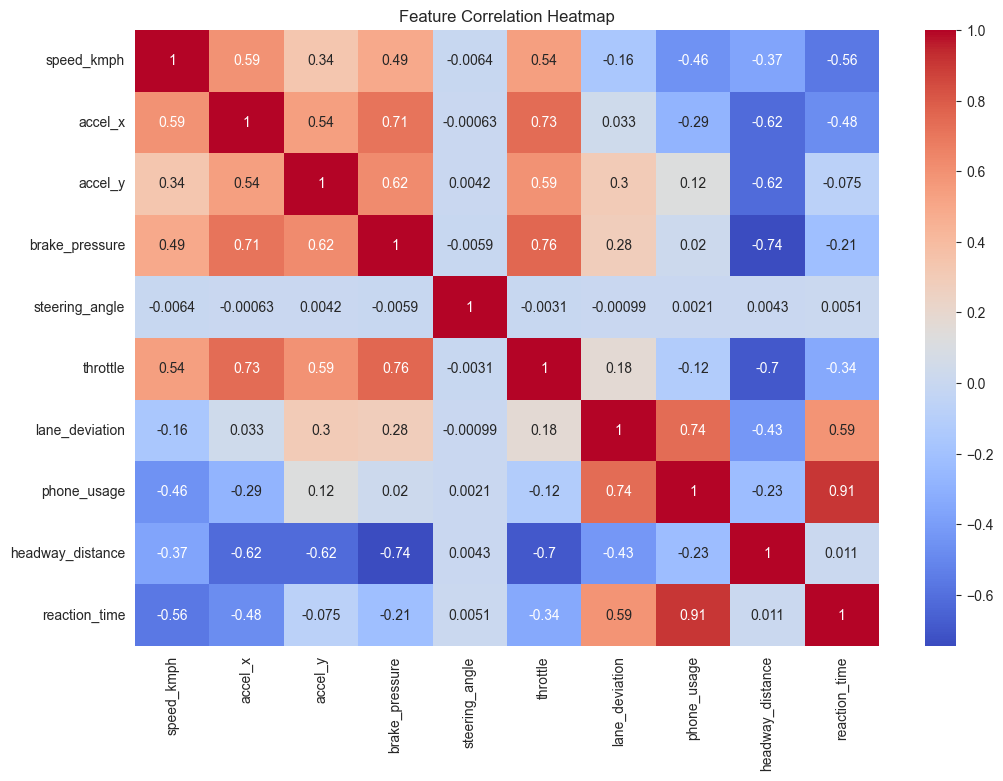

In [43]:
plt.figure(figsize=(12,8))
corr = df[feature_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


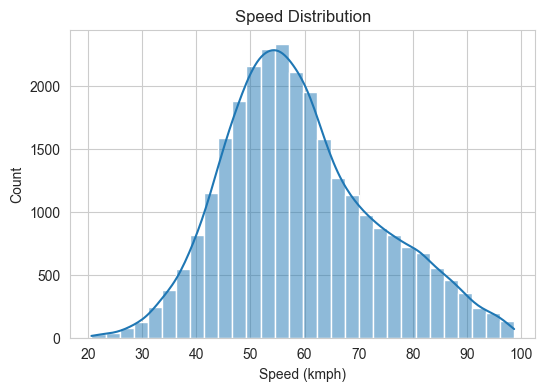

In [44]:
plt.figure(figsize=(6,4))
sns.histplot(df['speed_kmph'], bins=30, kde=True)
plt.title("Speed Distribution")
plt.xlabel("Speed (kmph)")
plt.show()

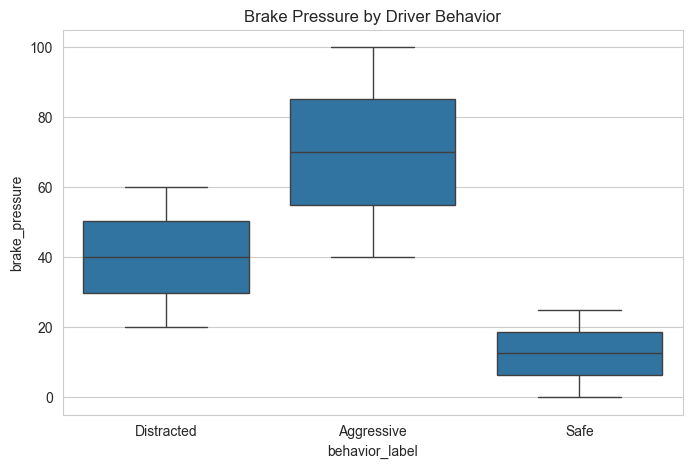

In [45]:
plt.figure(figsize=(8,5))
sns.boxplot(x='behavior_label', y='brake_pressure', data=df)
plt.title("Brake Pressure by Driver Behavior")
plt.show()

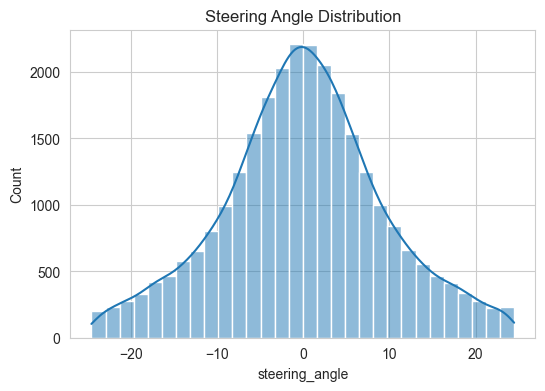

In [46]:
plt.figure(figsize=(6,4))
sns.histplot(df['steering_angle'], bins=30, kde=True)
plt.title("Steering Angle Distribution")
plt.show()

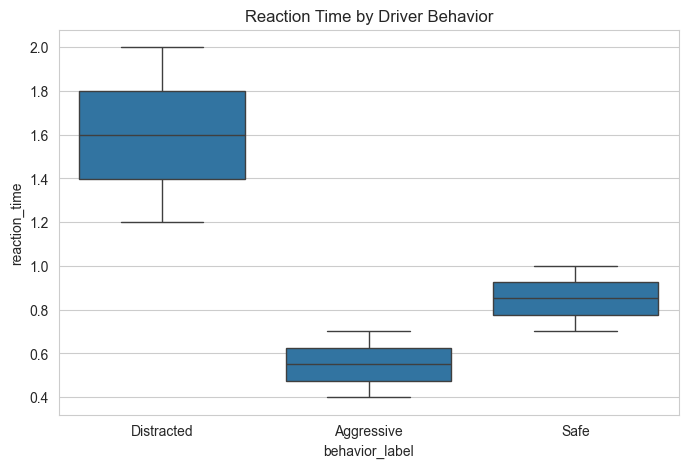

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x='behavior_label', y='reaction_time', data=df)
plt.title("Reaction Time by Driver Behavior")
plt.show()

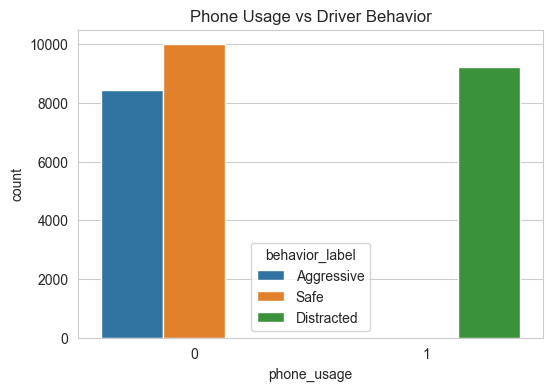

In [48]:
plt.figure(figsize=(6,4))
sns.countplot(x='phone_usage', hue='behavior_label', data=df)
plt.title("Phone Usage vs Driver Behavior")
plt.show()

In [49]:
df_scaled.to_csv("cleaned_driver_behavior.csv", index=False)

print("\nCleaned and transformed dataset saved successfully!")


Cleaned and transformed dataset saved successfully!
